In [4]:
# run first time
import sys
!{sys.executable} -m pip install "gymnasium[box2d]"==1.2.3
# !{sys.executable} -m pip install "gymnasium[box2d]" imageio statsmodels pyvirtualdisplay tensorflow matplotlib numpy "imageio[ffmpeg]"


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: /Users/wangrunyuan/.pyenv/versions/3.11.9/bin/python -m pip install --upgrade pip


In [7]:
import time
from collections import deque, namedtuple

import numpy as np
import PIL.Image
import tensorflow as tf
import utils
import matplotlib.pyplot as plt
from bidirection_lunar_lander import BidirectionalLunarLander

# from pyvirtualdisplay import Display
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.losses import MSE
from tensorflow.keras.optimizers import Adam

In [113]:
def navie_inverted_controller(obs, phase):
    x = obs[0]
    y = obs[1]
    vx = obs[2]
    vy = obs[3]
    theta = obs[4]
    omega = obs[5]

    # angle wrap to [-pi, pi]
    theta_wrapped = np.arctan2(np.sin(theta), np.cos(theta))
    theta_abs = abs(theta_wrapped)

    side = 0
    main = 0
    if phase == 1:
        if y > 1.4:
            return np.array([0, 0], dtype=np.float32), phase
            
        if theta_abs < 1.9:
            side = -0.6
            main = 0.8
        elif theta_abs > 1.9 and abs(omega) > 0.1 :
            side = 1
            main = -1
        else:
            phase = 2

    if phase == 2:
        if y > 1.4:
            return np.array([0, 0], dtype=np.float32), phase

        main = -0.6
        if vx > 0.1:
            side = 0.5
        elif vx < -0.1:
            side = -0.5
        else:
            side = 0

    return np.array([
        np.clip(main, -1.0, 1.0),
        np.clip(side, -1.0, 1.0)
    ], dtype=np.float32), phase

In [123]:
##### See what happens by calling navie inverted controller in 500 steps
env = BidirectionalLunarLander(continuous=True, render_mode="human")
obs, info = env.reset()

phase = 1
for step in range(500):
    action, phase = navie_inverted_controller(obs, phase)
    obs, reward, terminated, truncated, info = env.step(action)
    x = obs[0]
    vx = obs[2]
    theta = obs[4]
    omega = obs[5]
    theta_w = np.arctan2(np.sin(theta), np.cos(theta), )
    print(f"\rphase: {phase} action: {action} x: {x}, vx: {vx} theta: {theta_w}, omega: {omega}")

    if terminated or truncated:
        print(f"Episode ended: {step}")
        break

env.close

phase: 1 action: [0. 0.] x: 0.0010648727184161544, vx: 0.053843580186367035 theta: -0.0012135501019656658, omega: -0.01206762995570898
phase: 1 action: [0. 0.] x: 0.0015972137916833162, vx: 0.053845398128032684 theta: -0.0018166841473430395, omega: -0.012063892558217049
phase: 1 action: [0. 0.] x: 0.0021295547485351562, vx: 0.05384719371795654 theta: -0.0024197385646402836, omega: -0.01206215750426054
phase: 1 action: [0. 0.] x: 0.0026618957053869963, vx: 0.05384897440671921 theta: -0.003022689837962389, omega: -0.012060274370014668
phase: 1 action: [0. 0.] x: 0.0031943321228027344, vx: 0.05385076254606247 theta: -0.0036255603190511465, omega: -0.012058388441801071
phase: 1 action: [0. 0.] x: 0.0037267685402184725, vx: 0.05385255068540573 theta: -0.004228321835398674, omega: -0.012056496925652027
phase: 1 action: [0. 0.] x: 0.004259204957634211, vx: 0.0538543276488781 theta: -0.004830989986658096, omega: -0.01205458864569664
phase: 1 action: [0. 0.] x: 0.004791641142219305, vx: 0.05385

<bound method LunarLander.close of <bidirection_lunar_lander.BidirectionalLunarLander object at 0x31c84c950>>

In [128]:
def collect_one_episode(env, max_steps=500):
    obs, info = env.reset()
    phase = 1

    episode = []

    for t in range(max_steps):
        action, phase = navie_inverted_controller(obs, phase)

        episode.append({
            "obs": obs.copy(),
            "action": action.copy(),
            "phase": phase
        })

        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            break

    return episode


In [129]:
def collect_expert_episodes(
    env,
    num_episodes=300,
    min_length=30,
    require_inverted=True
):
    expert_episodes = []

    for ep in range(num_episodes):
        episode = collect_one_episode(env)

        if len(episode) < min_length:
            continue

        if require_inverted:
            phases = [step["phase"] for step in episode]
            if 2 not in phases:
                continue

        expert_episodes.append([
            {
                "obs": step["obs"],
                "action": step["action"]
            }
            for step in episode
        ])

        print(
            f"Accepted episode {len(expert_episodes)} "
            f"(len={len(episode)})"
        )

    print(f"\nCollected {len(expert_episodes)} expert episodes")
    return expert_episodes


In [130]:
def save_expert_episodes(expert_episodes, path="expert_lander.npz"):
    obs = []
    actions = []
    episode_lens = []

    for ep in expert_episodes:
        episode_lens.append(len(ep))
        for step in ep:
            obs.append(step["obs"])
            actions.append(step["action"])

    obs = np.array(obs, dtype=np.float32)
    actions = np.array(actions, dtype=np.float32)
    episode_lens = np.array(episode_lens, dtype=np.int32)

    np.savez(
        path,
        obs=obs,
        actions=actions,
        episode_lens=episode_lens
    )

    print(
        f"Saved {len(episode_lens)} episodes, "
        f"{len(obs)} total steps"
    )

In [131]:
env = BidirectionalLunarLander(continuous=True)
dataset = collect_expert_episodes(env, num_episodes=1000, min_length=50)
save_expert_episodes(dataset)

Accepted episode 1 (len=93)
Accepted episode 2 (len=154)
Accepted episode 3 (len=127)
Accepted episode 4 (len=285)
Accepted episode 5 (len=119)
Accepted episode 6 (len=130)
Accepted episode 7 (len=224)
Accepted episode 8 (len=121)
Accepted episode 9 (len=233)
Accepted episode 10 (len=141)
Accepted episode 11 (len=237)
Accepted episode 12 (len=180)
Accepted episode 13 (len=232)
Accepted episode 14 (len=500)
Accepted episode 15 (len=160)
Accepted episode 16 (len=111)
Accepted episode 17 (len=218)
Accepted episode 18 (len=205)
Accepted episode 19 (len=160)
Accepted episode 20 (len=178)
Accepted episode 21 (len=293)
Accepted episode 22 (len=194)
Accepted episode 23 (len=358)
Accepted episode 24 (len=119)
Accepted episode 25 (len=135)
Accepted episode 26 (len=192)
Accepted episode 27 (len=360)
Accepted episode 28 (len=266)
Accepted episode 29 (len=262)
Accepted episode 30 (len=88)
Accepted episode 31 (len=204)
Accepted episode 32 (len=157)
Accepted episode 33 (len=212)
Accepted episode 34 (

In [132]:
# Sanity check
data = np.load("expert_lander.npz")

obs_all = data["obs"]
actions_all = data["actions"]
episode_lens = data["episode_lens"]

env = BidirectionalLunarLander(
    continuous=True,
    render_mode="human"
)

ep_id = np.random.randint(len(episode_lens))

start = sum(episode_lens[:ep_id])
end = start + episode_lens[ep_id]

obs, _ = env.reset()

for t in range(start, end):
    obs, _, terminated, truncated, _ = env.step(actions_all[t])
    if terminated or truncated:
        break


In [133]:
data = np.load("expert_lander.npz")

obs_all = data["obs"]          # shape: (N, 8)
actions_all = data["actions"]  # shape: (N, 2)
episode_lens = data["episode_lens"]

dataset = tf.data.Dataset.from_tensor_slices(
    (obs_all.astype(np.float32), actions_all.astype(np.float32))
)

dataset = dataset.shuffle(10000).batch(256).prefetch(tf.data.AUTOTUNE)


In [134]:
## Behavior cloning
def build_bc_policy(obs_dim=8, act_dim=2):
    inputs = Input(shape=(obs_dim,))
    x = Dense(128, activation="relu")(inputs)
    x = Dense(128, activation="relu")(x)
    outputs = Dense(act_dim, activation="tanh")(x)

    model = Model(inputs, outputs)
    return model

In [135]:
policy = build_bc_policy()

policy.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="mse"
)

policy.fit(
    dataset,
    epochs=100
)

Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.1069
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.0483
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.0392
Epoch 4/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - loss: 0.0335
Epoch 5/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 0.0298
Epoch 6/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - loss: 0.0270
Epoch 7/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 0.0251
Epoch 8/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 0.0234
Epoch 9/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.0222
Epoch 10/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.0211
Epoch 11/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.0204
Epoch 12/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 0.0196
Epoch 13/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.0187
Epoch 14/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.0180
Epoch 15/100
52

In [151]:
env = BidirectionalLunarLander(
    continuous=True,
    render_mode="human"
)

obs, _ = env.reset()

for t in range(500):
    obs_batch = obs.reshape(1, -1).astype(np.float32)
    action = policy(obs_batch, training=False).numpy()[0]

    obs, _, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break

In [ ]:
#####################

In [5]:
# Set the random seed for TensorFlow
tf.random.set_seed(utils.SEED)

In [6]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-4              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps
MAX_TIME_LIMIT = 500      # max time limit
X_RANGE_INIT = 0.5
Y_RANGE_INIT = 0.3
X_RANGE_END = 0.01
Y_RANGE_END = 0.01

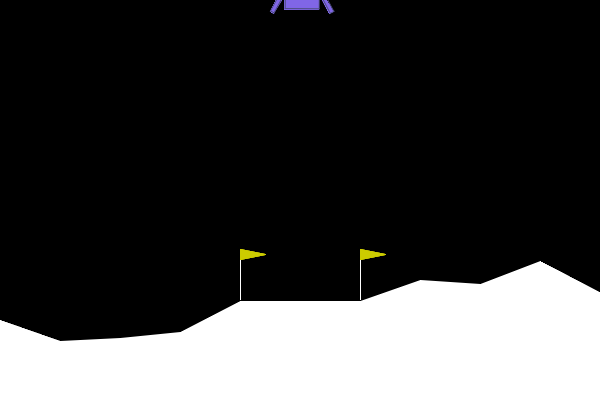

In [8]:
env.reset()
PIL.Image.fromarray(env.render())

In [9]:
# UNQ_C1
# GRADED CELL

state_size = env.observation_space.shape
num_actions = env.action_space.n

# Create the Q-Network
q_network = Sequential([
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    Input(shape=state_size),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_actions, activation='linear')
    ])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=ALPHA,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True
)
optimizer = Adam(learning_rate=lr_schedule)

In [10]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [11]:
# UNQ_C2
# GRADED FUNCTION: calculate_loss

def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """
    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    y_targets = rewards + (1.0 - done_vals) * gamma * max_qsa
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    # Compute the loss
    loss = MSE(y_targets, q_values)
    
    return loss

In [12]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network
    utils.update_target_network(q_network, target_q_network)

In [13]:
start = time.time()

num_episodes = 4000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # number of total points to use for averaging
epsilon = 1.0     # initial ε value for ε-greedy policy

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=MEMORY_SIZE)

# Set the target network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

step = 5
range_step_x = (X_RANGE_INIT - X_RANGE_END) / step
range_step_y = (Y_RANGE_INIT - Y_RANGE_END) / step
for i in range(step+1):   
    curr_x_range = X_RANGE_INIT - range_step_x * i
    curr_y_range = Y_RANGE_INIT - range_step_y * i
    env.unwrapped.update_range(x_range = curr_x_range, y_range = curr_y_range) 
    total_point_history = []
    print(f"\rStep{i}, x range: {curr_x_range}, y range: {curr_y_range}")
    
    for i in range(num_episodes):
        
        # Reset the environment to the initial state and get the initial state
        state, _ = env.reset()
        total_points = 0
        
        for t in range(max_num_timesteps):
            
            # From the current state S choose an action A using an ε-greedy policy
            state_qn = np.expand_dims(state, axis=0)  # state needs to be the right shape for the q_network
            q_values = q_network(state_qn)
            action = utils.get_action(q_values, epsilon)
            
            # Take action A and receive reward R and the next state S'
            next_state, reward, done, _, _ = env.step(action)
            
            # Store experience tuple (S,A,R,S') in the memory buffer.
            # We store the done variable as well for convenience.
            memory_buffer.append(experience(state, action, reward, next_state, done))
            
            # Only update the network every NUM_STEPS_FOR_UPDATE time steps.
            update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
            
            if update:
                # Sample random mini-batch of experience tuples (S,A,R,S') from D
                experiences = utils.get_experiences(memory_buffer)
                
                # Set the y targets, perform a gradient descent step,
                # and update the network weights.
                agent_learn(experiences, GAMMA)
            
            state = next_state.copy()
            total_points += reward
            
            if done:
                break
                
        total_point_history.append(total_points)
        av_latest_points = np.mean(total_point_history[-num_p_av:])
        
        # Update the ε value
        epsilon = utils.get_new_eps(epsilon)
    
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")
    
        if (i+1) % num_p_av == 0:
            print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")
    
        # We will consider that the environment is solved if we get an
        # average of 200 points in the last 100 episodes.
        if av_latest_points >= 200.0:
            print(f"\n\nEnvironment solved in {i+1} episodes!")
            q_network.save('lunar_lander_model.h5')
            break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Step0, x range: 0.5, y range: 0.3
Episode 100 | Total point average of the last 100 episodes: -238.39
Episode 200 | Total point average of the last 100 episodes: -100.14
Episode 300 | Total point average of the last 100 episodes: -65.042
Episode 400 | Total point average of the last 100 episodes: -72.64
Episode 500 | Total point average of the last 100 episodes: -75.54
Episode 600 | Total point average of the last 100 episodes: -55.22
Episode 700 | Total point average of the last 100 episodes: -27.01
Episode 800 | Total point average of the last 100 episodes: -36.28
Episode 900 | Total point average of the last 100 episodes: -25.83
Episode 1000 | Total point average of the last 100 episodes: -16.12
Episode 1100 | Total point average of the last 100 episodes: -37.63
Episode 1200 | Total point average of the last 100 episodes: -25.92
Episode 1300 | Total point average of the last 100 episodes: -19.10
Episode 1400 | Total point average of the last 100 episodes: -18.16
Episode 1500 | Total

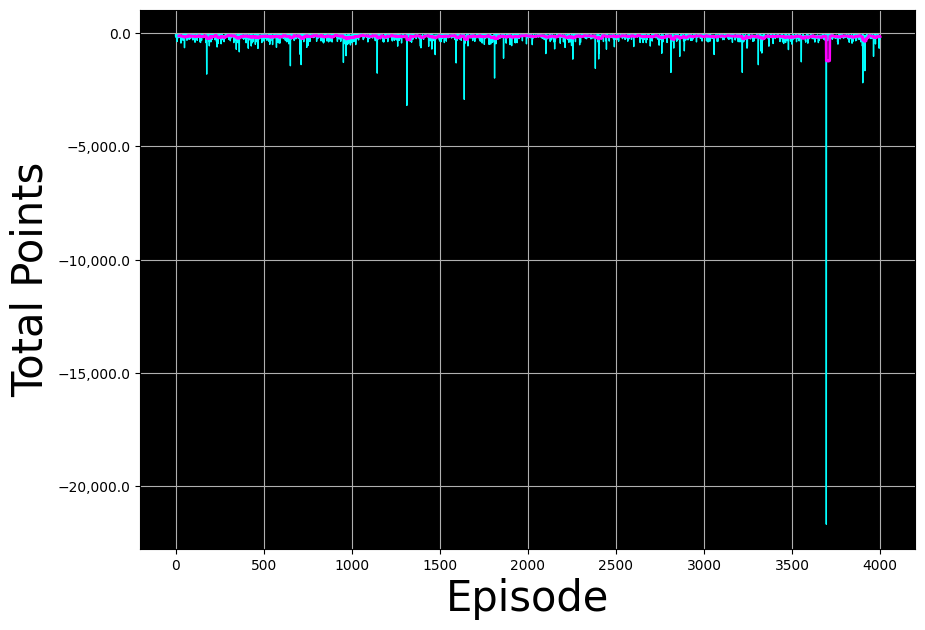

In [14]:
# Plot the point history
utils.plot_history(total_point_history)

In [15]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

In [16]:
filename = "./videos/lunar_lander.mp4"

utils.create_video(filename, env, q_network)
utils.embed_mp4(filename)